In [65]:
import pandas as pd
import numpy as np

In [66]:
data = pd.read_csv('./Datasets/used_car_dataset.csv')
data

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel
...,...,...,...,...,...,...
887,Ta,Tara,zest,"3,10,000",NaN,NaN
888,Tata Zest XM Diesel,Tata,2018,"2,60,000","27,000 kms",Diesel
889,Mahindra Quanto C8,Mahindra,2013,"3,90,000","40,000 kms",Diesel
890,Honda Amaze 1.2 E i VTEC,Honda,2014,"1,80,000",Petrol,NaN


In [67]:
data.dtypes

name          str
company       str
year          str
Price         str
kms_driven    str
fuel_type     str
dtype: object

# Cleaning Data

## Cleaning Name Column & Turning to Numbers

In [68]:
data['name']  = data['name'].astype('category').cat.codes
data

,name,company,year,Price,kms_driven,fuel_type
0,154,Hyundai,2007,"80,000","45,000 kms",Petrol
1,204,Mahindra,2006,"4,25,000",40 kms,Diesel
2,254,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,143,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,61,Ford,2014,"5,75,000","36,000 kms",Diesel
...,...,...,...,...,...,...
887,406,Tara,zest,"3,10,000",NaN,NaN
888,460,Tata,2018,"2,60,000","27,000 kms",Diesel
889,212,Mahindra,2013,"3,90,000","40,000 kms",Diesel
890,82,Honda,2014,"1,80,000",Petrol,NaN


## Cleaning Company Column

In [69]:
data['company'] = data['company'].astype('category').cat.codes
data

,name,company,year,Price,kms_driven,fuel_type
0,154,14,2007,"80,000","45,000 kms",Petrol
1,204,20,2006,"4,25,000",40 kms,Diesel
2,254,21,2018,Ask For Price,"22,000 kms",Petrol
3,143,14,2014,"3,25,000","28,000 kms",Petrol
4,61,11,2014,"5,75,000","36,000 kms",Diesel
...,...,...,...,...,...,...
887,406,31,zest,"3,10,000",NaN,NaN
888,460,32,2018,"2,60,000","27,000 kms",Diesel
889,212,20,2013,"3,90,000","40,000 kms",Diesel
890,82,13,2014,"1,80,000",Petrol,NaN


## Turning Year col to int

In [70]:
data["year"] = pd.to_numeric(data["year"], errors="coerce")

year_mean = data["year"].mean()

data["year"] = data["year"].fillna(year_mean)

data

,name,company,year,Price,kms_driven,fuel_type
0,154,14,2007.000000,"80,000","45,000 kms",Petrol
1,204,20,2006.000000,"4,25,000",40 kms,Diesel
2,254,21,2018.000000,Ask For Price,"22,000 kms",Petrol
3,143,14,2014.000000,"3,25,000","28,000 kms",Petrol
4,61,11,2014.000000,"5,75,000","36,000 kms",Diesel
...,...,...,...,...,...,...
887,406,31,2012.523753,"3,10,000",NaN,NaN
888,460,32,2018.000000,"2,60,000","27,000 kms",Diesel
889,212,20,2013.000000,"3,90,000","40,000 kms",Diesel
890,82,13,2014.000000,"1,80,000",Petrol,NaN


## Cleaning Price

In [71]:
data["Price"] = (
    data["Price"]
    .astype(str)  # ensure string (handles NaN)
    .str.replace(",", "", regex=False)  # remove all dots
    .apply(pd.to_numeric, errors="coerce")  # convert to float, invalid -> NaN
)


In [72]:

data["Price"] = data["Price"] / 10


In [73]:
price_mean = data["Price"].mean().round()

data["Price"] = data["Price"].fillna(price_mean)

data

,name,company,year,Price,kms_driven,fuel_type
0,154,14,2007.000000,8000.0,"45,000 kms",Petrol
1,204,20,2006.000000,42500.0,40 kms,Diesel
2,254,21,2018.000000,40469.0,"22,000 kms",Petrol
3,143,14,2014.000000,32500.0,"28,000 kms",Petrol
4,61,11,2014.000000,57500.0,"36,000 kms",Diesel
...,...,...,...,...,...,...
887,406,31,2012.523753,31000.0,NaN,NaN
888,460,32,2018.000000,26000.0,"27,000 kms",Diesel
889,212,20,2013.000000,39000.0,"40,000 kms",Diesel
890,82,13,2014.000000,18000.0,Petrol,NaN


## Cleaning Kilometers Driven Column

In [74]:
data["kms_driven"] = data["kms_driven"].str.replace(",", ".")
data["kms_driven"] = data["kms_driven"].str.replace("kms", "")
data["kms_driven"] = pd.to_numeric(data['kms_driven'], errors='coerce')

In [75]:
kms_median = data['kms_driven'].median()

data['kms_driven'] = data['kms_driven'].fillna(kms_median)
data

,name,company,year,Price,kms_driven,fuel_type
0,154,14,2007.000000,8000.0,45.0,Petrol
1,204,20,2006.000000,42500.0,40.0,Diesel
2,254,21,2018.000000,40469.0,22.0,Petrol
3,143,14,2014.000000,32500.0,28.0,Petrol
4,61,11,2014.000000,57500.0,36.0,Diesel
...,...,...,...,...,...,...
887,406,31,2012.523753,31000.0,40.0,NaN
888,460,32,2018.000000,26000.0,27.0,Diesel
889,212,20,2013.000000,39000.0,40.0,Diesel
890,82,13,2014.000000,18000.0,40.0,NaN


## Cleaning Fuel Type Column

In [76]:
data["fuel_type"] = data["fuel_type"].fillna("Petrol")
data['fuel_type'] = data['fuel_type'].astype('category').cat.codes
data

,name,company,year,Price,kms_driven,fuel_type
0,154,14,2007.000000,8000.0,45.0,2
1,204,20,2006.000000,42500.0,40.0,0
2,254,21,2018.000000,40469.0,22.0,2
3,143,14,2014.000000,32500.0,28.0,2
4,61,11,2014.000000,57500.0,36.0,0
...,...,...,...,...,...,...
887,406,31,2012.523753,31000.0,40.0,2
888,460,32,2018.000000,26000.0,27.0,0
889,212,20,2013.000000,39000.0,40.0,0
890,82,13,2014.000000,18000.0,40.0,2


# Seperating Datas

In [77]:
x = data.drop("Price", axis="columns").to_numpy()
y = data['Price'].to_numpy()

print(x, '\n', y)

[[1.540e+02 1.400e+01 2.007e+03 4.500e+01 2.000e+00]
 [2.040e+02 2.000e+01 2.006e+03 4.000e+01 0.000e+00]
 [2.540e+02 2.100e+01 2.018e+03 2.200e+01 2.000e+00]
 ...
 [2.120e+02 2.000e+01 2.013e+03 4.000e+01 0.000e+00]
 [8.200e+01 1.300e+01 2.014e+03 4.000e+01 2.000e+00]
 [3.300e+01 6.000e+00 2.014e+03 4.000e+01 2.000e+00]] 
 [  8000.   42500.   40469.   32500.   57500.   40469.   17500.   19000.
  83000.   25000.   18200.   31500.   41500.   32000.    8000.   42500.
 100000.   50000.   35000.   16000.   35000.   31000.    7500.   10000.
  10000.   10000.   19000.   29000.    9500.   18000.   38500.   25000.
  18000.   10500.   10500.   65000.   68999.9  44800.   54900.   50100.
  48999.9  28000.   25000.   34999.9  28499.9  34500.   49999.9  23500.
  24999.9 147500.   18000.   38500.   25000.   18000.   10500.   10500.
  39500.   22000.   17000.    8500.   17500.   19000.   20000.   83000.
  20000.   57000.   31500.   18200.   31500.   40469.   11000.   50100.
  44899.9 189111.1  23500.

# Plotting Data

In [78]:
import matplotlib.pyplot as plt

['name', 'company', 'year', 'kms_driven', 'fuel_type']


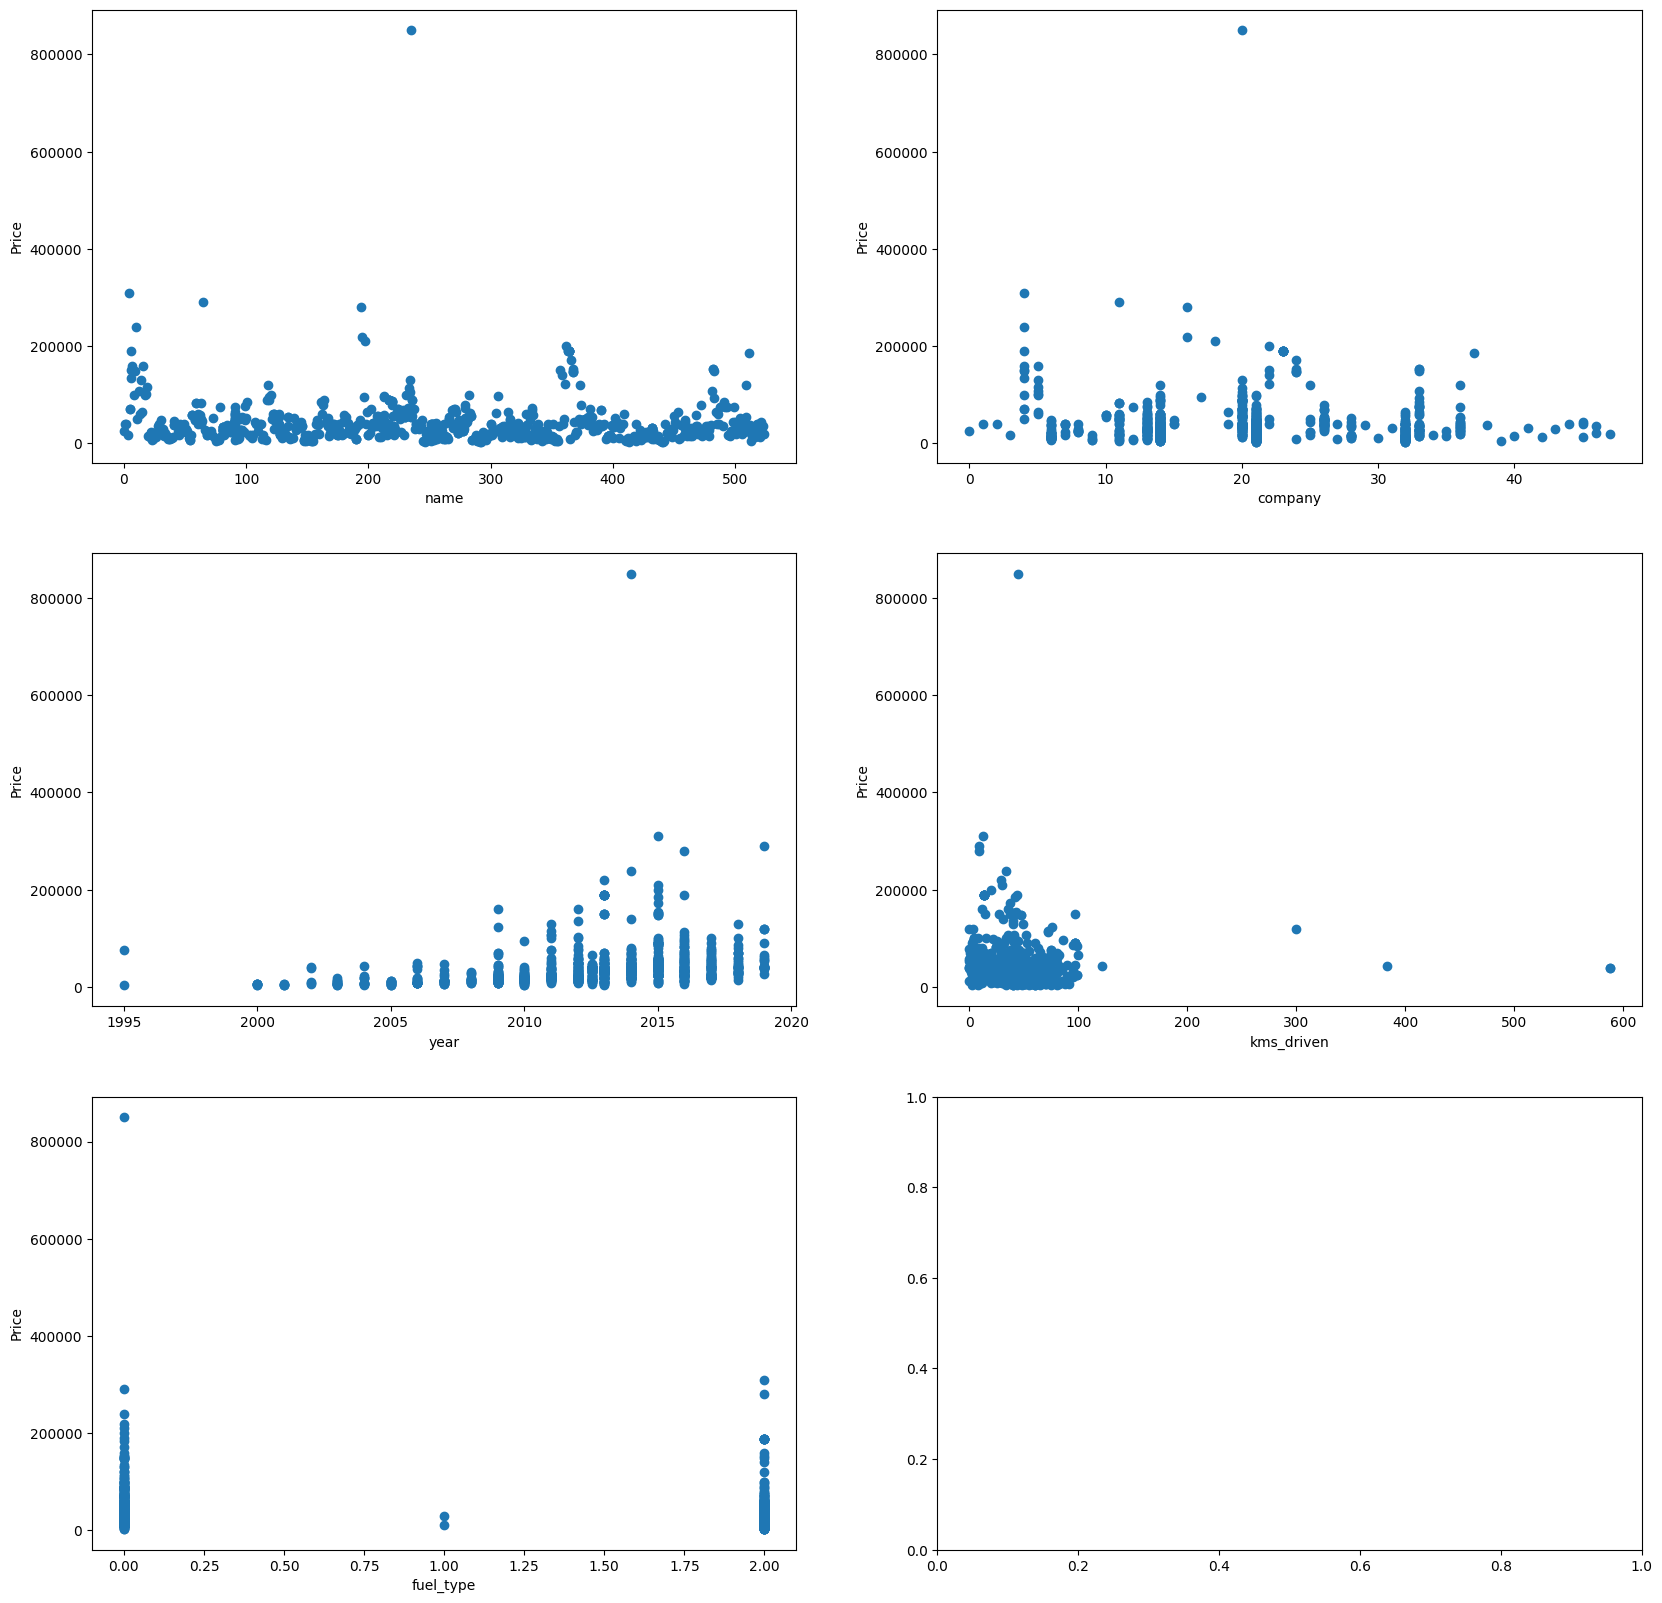

In [80]:
features = list(data.columns.values)
features.remove("Price")

print(features)

fig, plot = plt.subplots(3, 2, figsize=(20, 20))
plot = plot.ravel()

for i in range(5):
    plot[i].scatter(x[:, i], y)
    plot[i].set_xlabel(features[i])
    plot[i].set_ylabel("Price")

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

## Scaling Data

In [ ]:
scaler = StandardScaler().fit(x)

x_scaled = scaler.transform(x)

array([[-7.03771068e-01, -7.30327702e-01, -1.41350009e+00,
         7.09096445e-02,  8.94541286e-01],
       [-3.46762541e-01, -8.17836173e-04, -1.66939496e+00,
        -6.81047333e-02, -1.12043555e+00],
       [ 1.02459846e-02,  1.20767142e-01,  1.40134356e+00,
        -5.68556494e-01,  8.94541286e-01],
       ...,
       [-2.89641177e-01, -8.17836173e-04,  1.21869175e-01,
        -6.81047333e-02, -1.12043555e+00],
       [-1.21786335e+00, -8.51912680e-01,  3.77764053e-01,
        -6.81047333e-02,  8.94541286e-01],
       [-1.56773170e+00, -1.70300752e+00,  3.77764053e-01,
        -6.81047333e-02,  8.94541286e-01]], shape=(892, 5))

## Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x_scaled, y)

[[ 1.54538265  1.57978687 -0.64581546 -0.12371048 -1.12043555]
 [ 0.45293656  0.12076714 -0.38992058  0.62696716 -1.12043555]
 [ 1.04557071  0.97186199  0.12186918  0.20992402 -1.12043555]
 ...
 [ 1.53110231  1.57978687 -0.64581546  0.76598153  0.89454129]
 [-1.36066676 -1.09508264  1.14544868 -0.902191    0.89454129]
 [ 0.53147843  0.12076714 -0.1340257   0.15448509 -1.12043555]] [[ 1.08841173  1.21503194  0.         -0.06810473  0.89454129]
 [ 0.88134679  0.72869203  0.12186918 -0.09590761 -1.12043555]
 [ 1.85955015  2.30929674  0.         -0.06810473  0.89454129]
 ...
 [ 0.43151605  0.12076714  0.37776405  0.04310677  0.89454129]
 [-0.03259504  0.12076714 -1.92528984 -0.06810473  0.89454129]
 [-0.79659328 -0.7303277   0.37776405 -0.04030186  0.89454129]] [ 35100.   14000.   37499.9  12000.    9999.9  12000.    7500.   80000.
  40000.   12000.   68999.9  56000.   10000.    4900.   22500.   22500.
  17499.9  37500.   59900.   40469.   22000.   11000.  100000.   40191.9
  25000.   5900

In [88]:
regr = LinearRegression()
regr.fit(X_train, y_train)

print(regr.score(X_train, y_train))

0.10182887224446746
